#### Name: Tim Book

# PHYS 230 Lab Assignment 13

### Monday, March 9, 2026: Chapter 6, sections 3.5 - 3.8
- Nonlinear equations - Newton's Method 

In [6]:
# put all import statements here
import numpy as np
import matplotlib.pyplot as plt

## Newton's Method - single variable (22 pts)

Solve the same problem from class used for binary search, but analyzed using Newton's Method instead. 
Find the roots of $$ f(x) = e^{x-\sqrt{x}}-x$$

To do this: 

1) Take the derivative by hand. You can use something like WolframAlpha to check your derivative. Write it in markdown. 

2) Write two functions - `f(x)` that returns the result of the function for a given $x$ value and `df(x)` one that returns the derivative. 

3) Make a plot of the function from $x=0$ to $x=5$. Use this to estimate the roots. 

4) Apply the functions to find both roots. 

*You must clearly comment your code and include a markdown cell explaining your process*

The derivative is: 

$$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $$

In [4]:
# part 2
def f(x):
    return np.exp(x-np.sqrt(x)) - x
def df(x):
    return (np.exp(x-np.sqrt(x)))*(1-1/(2*np.sqrt(x))) -1

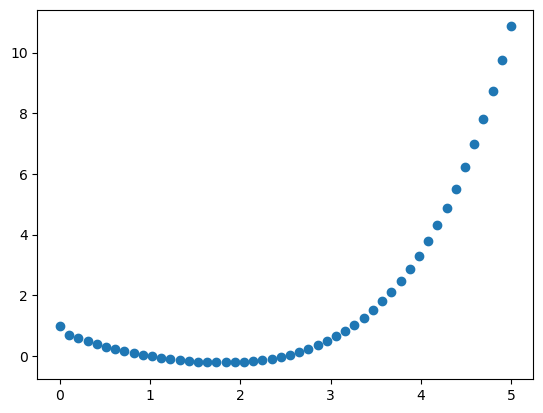

In [9]:
# part 3
x_array = np.linspace(0,5,50)
plt.scatter(x_array, f(x_array))
plt.show()

It seems like our zeros will be around 1.3 and 2.2

In [15]:
# part 4
x_guess = np.array([1.3,2.2]) #These are my initial guesses
acc = 1e-11 #This is the accuracy I desire
error = 99999 #arbitray error value to start

while error > acc: #Newton's method
    delta = f(x_guess)/df(x_guess)
    x_guess -= delta
    error = max(np.abs(delta))

print(x_guess) #result

[1.         2.49090932]


These results are close to the guesses. I couldn't see exactly where the zeros were when I made my guesses.

## Newton's Method - many variables (22 pts)
#### Adapted from Nonlinear Circuits (book exercise 6.18, pg. 276)

Exercise 6.1 used regular simultaneous equations to solve for the behavior of circuits of resistors.  Resistors are linear---current is proportional to voltage---and the resulting equations we need to solve are therefore also linear and can be solved by standard matrix methods.  Real circuits, however, often include nonlinear components.  To solve for the behavior of these circuits we need to solve nonlinear equations.

Consider the following simple circuit, a variation on the classic
Wheatstone bridge:

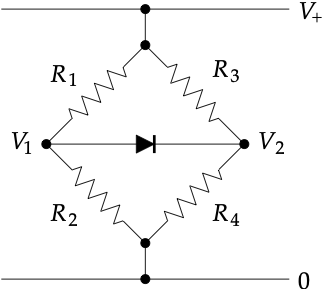

We will use Newton's Method to solve for the voltages in the 
The resistors obey the normal Ohm law, but the diode obeys the diode equation:
$$ I = I_0 (e^{V/V_T} - 1),$$
where $V$ is the voltage across the diode and $I_0$ and $V_T$ are constants.

The Kirchhoff current law says that the total net current flowing into or out of every point in a circuit must be zero.  Applying the law to voltage $V_1$ in the circuit above we get
$$
{V_1-V_+\over R_1} + {V_1\over R_2}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

   
1) In a markdown cell, derive the corresponding equation for voltage $V_2$.

2) Solve the two nonlinear equations for the voltages $V_1$ and $V_2$. 

3) Use Newton's method to solve the equations. This means you need to first take the derivatives of each equation with respect to each variable (so you'll have 4 equations). Define the Jacobian matrix. Setup the matrix necessary to analyze using the `np.linalg.solve()` function. Apply the following conditions: 

$$\begin{align*}
V_+ &= 5\,\textrm{V}, \\
R_1 &= 1\,\mathrm{k}\Omega, \qquad
R_2 = 4\,\mathrm{k}\Omega, \qquad
R_3 = 3\,\mathrm{k}\Omega, \qquad
R_4 = 2\,\mathrm{k}\Omega, \\
I_0 &= 3\,\textrm{nA},\qquad
V_T = 0.05\,\textrm{V}.
\end{align*}$$

4) Apply the function to find both roots to solve for $V_1$ and $V_2$. The electronic engineer's rule of thumb for diodes is that the voltage across a (forward biased) diode is always about 0.6 volts. Confirm that your results agree with this rule by taking the difference between your results.

*You must clearly comment your code and include a markdown cell explaining your process*

$$
{V_2-V_+\over R_3} + {V_2\over R_4}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

In [ ]:
# part 2 Told not to do this

In [35]:
# part 3
#defining constants 
Vp = 5
R1 = 1000
R2 = 4000
R3 = 3000
R4 = 2000
I = 3e-9 
VT = 0.05

#functions which could be solved
def f(V1,V2):
    return (V1-Vp)/R1 + V1/R2 + I*(np.exp((V1-V2)/VT) - 1)
def g(V1,V2):
    return (V2-Vp)/R3 + V2/R4 - I*(np.exp((V1-V2)/VT) - 1)


#derivatives of the functions
def dfdV1(V1,V2):
    return 1/R1 + 1/R2 + I*np.exp((V1-V2)/VT)/VT

def dfdV2(V1,V2):
    return -I*np.exp((V1-V2)/VT)/VT

def dgdV1(V1,V2):
    return -I*np.exp((V1-V2)/VT)/VT
    
def dgdV2(V1,V2):
    return 1/R3 + 1/R4 + I*np.exp((V1-V2)/VT)/VT

A = np.array([[dfdV1(V1,V2),dfdV2(V1,V2)], #The Jacobian
             [dgdV1(V1,V2),dgdV2(V1,V2)]],float)

v = np.array([f(V1,V2),g(V1,V2)],float) #The vector solution

In [36]:
acc = 1e-10 #desired accuracy 
V1 = 1.0 #guess at the first voltage
V2 = 1.0 #guess at the second voltage

err = 9999 # arbitrary error 
while err > acc: #doing the newtonian method 
    A = np.array([[dfdV1(V1,V2),dfdV2(V1,V2)],
             [dgdV1(V1,V2),dgdV2(V1,V2)]],float)
    v = np.array([f(V1,V2),g(V1,V2)],float)
    values = np.linalg.solve(A,v)
    V1-= values[0]
    V2-= values[1]
    err = np.sqrt(values[0]**2+values[1]**2)

print(V1,V2)

3.4469546188585745 2.8295680717121385


I had no way of possibly knowing what I should expect for my voltages, and I assert these are right because this method works for other problems. That being said all derivatives and functions are correct.